# Polymarket US-Iran Ceasefire Case Study (Dune)

This notebook identifies wallets that bet big on the `us-x-iran-ceasefire-by` event during the 5 hours before the anchor timestamp.

**Locked settings**
- Anchor: `2026-04-07 22:32:00 UTC`
- Pre-window: 5 hours (`2026-04-07 17:32:00` to `22:32:00` UTC)
- Scope: all event submarkets created before anchor
- Big bet logic: wallet-aggregated notional, percentile + floor
- Wallet timing: both `created_time` and `first_funded_time`


Scope note: this run is narrowed to the April 7 submarket under `us-x-iran-ceasefire-by`.


In [61]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from dotenv import load_dotenv
except ImportError:
    load_dotenv = None

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)


## 1) Configuration


In [62]:
# Core event configuration
EVENT_SLUG = "us-x-iran-ceasefire-by"
ANCHOR_TS_UTC = pd.Timestamp("2026-04-07T22:32:00Z")
PRE_WINDOW_HOURS = 5
PRE_WINDOW_START_UTC = ANCHOR_TS_UTC - pd.Timedelta(hours=PRE_WINDOW_HOURS)

# API settings
GAMMA_BASE = "https://gamma-api.polymarket.com"
DUNE_API_BASE = "https://api.dune.com/api/v1"

# API key from local .env or environment
if load_dotenv is not None:
    load_dotenv()

DUNE_API_KEY = os.getenv("DUNE_API_KEY", "").strip()

# Outputs
OUTPUT_DIR = Path("./polymarket_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Anchor UTC:", ANCHOR_TS_UTC)
print("Pre-window:", PRE_WINDOW_START_UTC, "to", ANCHOR_TS_UTC)
print("DUNE_API_KEY present:", bool(DUNE_API_KEY))
if load_dotenv is None:
    print("Tip: install python-dotenv to auto-load .env (pip install python-dotenv)")


Anchor UTC: 2026-04-07 22:32:00+00:00
Pre-window: 2026-04-07 17:32:00+00:00 to 2026-04-07 22:32:00+00:00
DUNE_API_KEY present: True


## 2) Polymarket Event Pull (Gamma)


In [63]:
def gamma_get(path: str, params: dict | None = None) -> list | dict:
    r = requests.get(f"{GAMMA_BASE}{path}", params=params or {}, timeout=30)
    r.raise_for_status()
    return r.json()


def load_event_by_slug(slug: str) -> dict:
    data = gamma_get("/events", params={"slug": slug})
    if isinstance(data, list) and data:
        return data[0]
    if isinstance(data, dict) and data:
        return data
    raise ValueError(f"Event not found for slug={slug}")


def parse_market_launch_time(df: pd.DataFrame) -> pd.Series:
    created = pd.to_datetime(df.get("createdAt"), errors="coerce", utc=True)
    started = pd.to_datetime(df.get("startDate"), errors="coerce", utc=True)
    launch = started.combine_first(created)
    return launch


event = load_event_by_slug(EVENT_SLUG)
print("event_id:", event.get("id"))
print("event_title:", event.get("title"))
print("event_closed:", event.get("closed"))

submarkets = pd.json_normalize(event.get("markets", []), sep=".")
if submarkets.empty:
    raise ValueError("No submarkets found under target event.")

for c in ["createdAt", "startDate", "endDate", "updatedAt"]:
    if c in submarkets.columns:
        submarkets[c] = pd.to_datetime(submarkets[c], errors="coerce", utc=True)

for c in ["volume", "liquidity", "lastTradePrice", "bestBid", "bestAsk"]:
    if c in submarkets.columns:
        submarkets[c] = pd.to_numeric(submarkets[c], errors="coerce")

submarkets["launch_time"] = parse_market_launch_time(submarkets)
submarkets_pre_anchor = submarkets[submarkets["launch_time"] <= ANCHOR_TS_UTC].copy()

keep_cols = [c for c in [
    "id", "slug", "question", "active", "closed", "launch_time", "createdAt", "startDate", "endDate", "volume", "liquidity", "conditionId", "clobTokenIds"
] if c in submarkets_pre_anchor.columns]

print(f"Submarkets total: {len(submarkets):,}")
print(f"Submarkets pre-anchor: {len(submarkets_pre_anchor):,}")
display(submarkets_pre_anchor.sort_values("volume", ascending=False)[keep_cols].head(30))

submarkets_pre_anchor.to_csv(OUTPUT_DIR / "case_ceasefire_selected_submarkets.csv", index=False)
print("Saved:", OUTPUT_DIR / "case_ceasefire_selected_submarkets.csv")


event_id: 236840
event_title: US x Iran ceasefire by...?
event_closed: True
Submarkets total: 12
Submarkets pre-anchor: 12


,id,slug,question,active,closed,launch_time,createdAt,startDate,endDate,volume,conditionId,clobTokenIds
9,1706788,us-x-iran-ceasefire-by-april-7,US x Iran ceasefire by April 7?,True,True,2026-03-24 17:55:37.794489+00:00,2026-03-24 17:52:05.724561+00:00,2026-03-24 17:55:37.794489+00:00,2026-04-07 00:00:00+00:00,1.736962e+08,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,"[""82855088893985825781350466813737280564000275..."
0,1466015,us-x-iran-ceasefire-by-march-31,US x Iran ceasefire by March 31?,True,True,2026-02-28 13:55:27.406367+00:00,2026-02-28 13:44:02.418340+00:00,2026-02-28 13:55:27.406367+00:00,NaT,4.437600e+07,0x3c6bcb7da14ea576e5af25547dbd96f2bb24ac34e748...,"[""57085616606014598055128171316012304939715897..."
8,1569627,us-x-iran-ceasefire-by-april-15,US x Iran ceasefire by April 15?,True,True,2026-03-12 17:06:47.252000+00:00,2026-03-12 16:42:24.632357+00:00,2026-03-12 17:06:47.252000+00:00,2026-04-15 00:00:00+00:00,2.462155e+07,0x773abaa5fe55e5cde51a261f444b7921652a4e059ead...,"[""85191934649046129480174964255278880752271767..."
1,1466016,us-x-iran-ceasefire-by-april-30,US x Iran ceasefire by April 30?,True,True,2026-02-28 13:55:23.403000+00:00,2026-02-28 13:44:03.127118+00:00,2026-02-28 13:55:23.403000+00:00,NaT,1.772688e+07,0x80059ff4e694f878c0498f6f3a067ee7ca62dc2fc462...,"[""44149007410374101286260953227333745102128417..."
7,1484894,us-x-iran-ceasefire-by-may-825,US x Iran ceasefire by May 31?,True,True,2026-03-02 17:21:12.961000+00:00,2026-03-02 17:03:42.044363+00:00,2026-03-02 17:21:12.961000+00:00,2026-05-31 00:00:00+00:00,7.793716e+06,0xa9937410f8aae98cc6440a7480ad832be5a1a998afcf...,"[""97390751868769233430161550786035197721004217..."
6,1484895,us-x-iran-ceasefire-by-june-30,US x Iran ceasefire by June 30?,True,True,2026-03-02 17:51:15.382000+00:00,2026-03-02 17:04:03.295238+00:00,2026-03-02 17:51:15.382000+00:00,2026-06-30 00:00:00+00:00,5.033124e+06,0x81b06cb917c9a2aabc67a7765bc3c640e88a699bbf45...,"[""91234452361450605263734013436205650165110345..."
4,1466012,us-x-iran-ceasefire-by-march-2,US x Iran ceasefire by March 2?,True,True,2026-02-28 13:55:25.297000+00:00,2026-02-28 13:44:00.441254+00:00,2026-02-28 13:55:25.297000+00:00,NaT,3.493959e+06,0x184f4a327edc0cd0af1f409980f6cc8d227fa9685562...,"[""89776833499647348615695457645016543876782311..."
5,1571566,us-x-iran-ceasefire-by-december-31,US x Iran ceasefire by December 31?,True,True,2026-03-12 21:33:38.098000+00:00,2026-03-12 21:30:30.966459+00:00,2026-03-12 21:33:38.098000+00:00,2026-12-31 00:00:00+00:00,2.113671e+06,0x4ccff8c606ad71080c7611d28f1593a528a8ca6c11c1...,"[""81289454586466989038065696325544201866984980..."
11,1912494,us-x-iran-ceasefire-by-april-10,US x Iran ceasefire by April 10?,True,True,2026-04-07 21:54:59.039461+00:00,2026-04-07 21:50:59.559310+00:00,2026-04-07 21:54:59.039461+00:00,2026-04-10 00:00:00+00:00,8.666577e+05,0x0de3f76fe9b60857833856bec4f30d815cdb0c283361...,"[""79960339234673242042984505667380376808663520..."
10,1896585,us-x-iran-ceasefire-by-may,US x Iran ceasefire by May 15?,True,True,2026-04-06 21:27:57.779000+00:00,2026-04-06 21:22:28.129696+00:00,2026-04-06 21:27:57.779000+00:00,2026-05-15 00:00:00+00:00,4.198455e+05,0xd9a8b5917a3bc25caf28784fddac39bc45a9f2fe4c63...,"[""72218628059411750242900835703049011068181898..."


Saved: polymarket_outputs/case_ceasefire_selected_submarkets.csv


## 3) Dune API Helpers


In [64]:
def dune_headers(api_key: str) -> dict:
    return {"X-Dune-Api-Key": api_key, "Content-Type": "application/json"}


def dune_execute_sql(sql: str, api_key: str, performance: str = "medium") -> str:
    if not api_key:
        raise ValueError("Missing DUNE_API_KEY. Set env var DUNE_API_KEY.")

    r = requests.post(
        f"{DUNE_API_BASE}/sql/execute",
        headers=dune_headers(api_key),
        json={"sql": sql, "performance": performance},
        timeout=30,
    )
    if not r.ok:
        raise RuntimeError(f"Dune execute failed: HTTP {r.status_code} | {r.text[:500]}")

    out = r.json()
    execution_id = out.get("execution_id")
    if not execution_id:
        raise RuntimeError(f"No execution_id returned: {out}")
    return execution_id


def dune_get_execution_status(execution_id: str, api_key: str) -> dict:
    r = requests.get(
        f"{DUNE_API_BASE}/execution/{execution_id}/status",
        headers=dune_headers(api_key),
        timeout=30,
    )
    if not r.ok:
        raise RuntimeError(f"Dune status failed: HTTP {r.status_code} | {r.text[:500]}")
    return r.json()


def dune_get_execution_results(
    execution_id: str,
    api_key: str,
    allow_partial_results: bool = True,
    limit: int | None = None,
) -> dict:
    params = {"allow_partial_results": str(allow_partial_results).lower()}
    if limit is not None:
        params["limit"] = int(limit)

    r = requests.get(
        f"{DUNE_API_BASE}/execution/{execution_id}/results",
        headers=dune_headers(api_key),
        params=params,
        timeout=60,
    )
    if not r.ok:
        raise RuntimeError(f"Dune results failed: HTTP {r.status_code} | {r.text[:500]}")
    return r.json()


def dune_run_sql(
    sql: str,
    api_key: str,
    performance: str = "medium",
    poll_interval_seconds: float = 2.0,
    timeout_seconds: float = 300,
    limit: int | None = None,
) -> dict:
    execution_id = dune_execute_sql(sql=sql, api_key=api_key, performance=performance)
    deadline = time.time() + timeout_seconds

    while True:
        status = dune_get_execution_status(execution_id, api_key=api_key)
        state = status.get("state")

        if state in {"QUERY_STATE_COMPLETED", "QUERY_STATE_COMPLETED_PARTIAL"}:
            return dune_get_execution_results(execution_id, api_key=api_key, allow_partial_results=True, limit=limit)

        if state in {"QUERY_STATE_FAILED", "QUERY_STATE_CANCELED", "QUERY_STATE_EXPIRED"}:
            raise RuntimeError(f"Dune query failed: {status}")

        if time.time() > deadline:
            raise TimeoutError(f"Timed out waiting for Dune execution {execution_id}")

        time.sleep(poll_interval_seconds)


def dune_rows_to_df(result_payload: dict) -> pd.DataFrame:
    rows = result_payload.get("result", {}).get("rows", []) if isinstance(result_payload, dict) else []
    return pd.DataFrame(rows)


def sql_quote(value: str) -> str:
    return "'" + str(value).replace("'", "''") + "'"


## 4) Resolve Selected Submarkets to Dune Market Identifiers


In [65]:
dune_market_map = pd.DataFrame()

selected_questions = sorted({
    str(x).strip().lower()
    for x in submarkets_pre_anchor.get("question", pd.Series(dtype=str)).dropna().tolist()
    if str(x).strip()
})
selected_condition_ids = sorted({
    str(x).strip().lower()
    for x in submarkets_pre_anchor.get("conditionId", pd.Series(dtype=str)).dropna().tolist()
    if str(x).strip()
})
selected_condition_ids = [x if x.startswith("0x") else f"0x{x}" for x in selected_condition_ids]

print("Selected pre-anchor condition IDs:", len(selected_condition_ids))

if submarkets_pre_anchor.empty:
    print("No pre-anchor submarkets to map.")
elif not DUNE_API_KEY:
    raise RuntimeError("DUNE_API_KEY missing.")
elif not selected_condition_ids:
    raise RuntimeError("No condition IDs found in selected submarkets.")
else:
    condition_sql = ", ".join(sql_quote(c) for c in selected_condition_ids)
    mapping_sql = f"""
    SELECT DISTINCT
        condition_id,
        event_market_name,
        question,
        token_outcome,
        token_outcome_name,
        unique_key
    FROM polymarket_polygon.market_details
    WHERE lower(condition_id) IN ({condition_sql})
    ORDER BY question, token_outcome
    """

    mapping_res = dune_run_sql(mapping_sql, api_key=DUNE_API_KEY, performance="medium", limit=20000)
    dune_market_map = dune_rows_to_df(mapping_res)

    print("Mapped rows:", len(dune_market_map))
    if not dune_market_map.empty:
        display(dune_market_map.head(50))

    dune_market_map.to_csv(OUTPUT_DIR / "case_ceasefire_dune_market_map.csv", index=False)
    print("Saved:", OUTPUT_DIR / "case_ceasefire_dune_market_map.csv")


Selected pre-anchor condition IDs: 12
Mapped rows: 24


,condition_id,event_market_name,question,token_outcome,token_outcome_name,unique_key
0,0x0de3f76fe9b60857833856bec4f30d815cdb0c283361...,single market,US x Iran ceasefire by April 10?,No,No-US x Iran ceasefire by April 10?,0x0de3f76fe9b60857833856bec4f30d815cdb0c283361...
1,0x0de3f76fe9b60857833856bec4f30d815cdb0c283361...,single market,US x Iran ceasefire by April 10?,Yes,Yes-US x Iran ceasefire by April 10?,0x0de3f76fe9b60857833856bec4f30d815cdb0c283361...
2,0x773abaa5fe55e5cde51a261f444b7921652a4e059ead...,single market,US x Iran ceasefire by April 15?,No,No-US x Iran ceasefire by April 15?,0x773abaa5fe55e5cde51a261f444b7921652a4e059ead...
3,0x773abaa5fe55e5cde51a261f444b7921652a4e059ead...,single market,US x Iran ceasefire by April 15?,Yes,Yes-US x Iran ceasefire by April 15?,0x773abaa5fe55e5cde51a261f444b7921652a4e059ead...
4,0x80059ff4e694f878c0498f6f3a067ee7ca62dc2fc462...,single market,US x Iran ceasefire by April 30?,No,No-US x Iran ceasefire by April 30?,0x80059ff4e694f878c0498f6f3a067ee7ca62dc2fc462...
5,0x80059ff4e694f878c0498f6f3a067ee7ca62dc2fc462...,single market,US x Iran ceasefire by April 30?,Yes,Yes-US x Iran ceasefire by April 30?,0x80059ff4e694f878c0498f6f3a067ee7ca62dc2fc462...
6,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,single market,US x Iran ceasefire by April 7?,No,No-US x Iran ceasefire by April 7?,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...
7,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,single market,US x Iran ceasefire by April 7?,Yes,Yes-US x Iran ceasefire by April 7?,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...
8,0x4ccff8c606ad71080c7611d28f1593a528a8ca6c11c1...,single market,US x Iran ceasefire by December 31?,No,No-US x Iran ceasefire by December 31?,0x4ccff8c606ad71080c7611d28f1593a528a8ca6c11c1...
9,0x4ccff8c606ad71080c7611d28f1593a528a8ca6c11c1...,single market,US x Iran ceasefire by December 31?,Yes,Yes-US x Iran ceasefire by December 31?,0x4ccff8c606ad71080c7611d28f1593a528a8ca6c11c1...


Saved: polymarket_outputs/case_ceasefire_dune_market_map.csv


## 5) Pull Pre-Window Trades from Dune


In [66]:
pre_trades = pd.DataFrame()

if submarkets_pre_anchor.empty:
    print("No selected submarkets; skipping trade pull.")
elif not DUNE_API_KEY:
    raise RuntimeError("DUNE_API_KEY missing.")
elif not selected_condition_ids:
    raise RuntimeError("No selected condition IDs available for trade pull.")
else:
    start_iso = PRE_WINDOW_START_UTC.strftime("%Y-%m-%dT%H:%M:%SZ")
    end_iso = ANCHOR_TS_UTC.strftime("%Y-%m-%dT%H:%M:%SZ")
    APRIL7_QUESTION_KEYWORD = "april 7"
    condition_sql = ", ".join(sql_quote(c) for c in selected_condition_ids)

    trade_sql = f"""
    SELECT
        date_trunc('month', block_time) AS block_month,
        block_number,
        block_time,
        lower(concat('0x', to_hex(tx_hash))) AS tx_hash,
        evt_index,
        action,
        lower(concat('0x', to_hex(contract_address))) AS contract_address,
        lower(concat('0x', to_hex(condition_id))) AS condition_id,
        event_market_name,
        question,
        token_outcome,
        CAST(asset_id AS VARCHAR) AS asset_id,
        price,
        amount,
        shares,
        lower(concat('0x', to_hex(maker))) AS maker,
        lower(concat('0x', to_hex(taker))) AS taker,
        unique_key,
        token_outcome_name
    FROM polymarket_polygon.market_trades
    WHERE block_time >= from_iso8601_timestamp('{start_iso}')
      AND block_time < from_iso8601_timestamp('{end_iso}')
      AND lower(concat('0x', to_hex(condition_id))) IN ({condition_sql})
      AND lower(question) LIKE '%{APRIL7_QUESTION_KEYWORD}%'
      AND amount > 500
    ORDER BY block_time
    """

    trade_res = dune_run_sql(trade_sql, api_key=DUNE_API_KEY, performance="medium", limit=500000)
    pre_trades = dune_rows_to_df(trade_res)

if pre_trades.empty:
    print("No pre-window trades returned.")
else:
    pre_trades["block_month"] = pd.to_datetime(pre_trades["block_month"], errors="coerce", utc=True)
    pre_trades["block_time"] = pd.to_datetime(pre_trades["block_time"], errors="coerce", utc=True)
    pre_trades["block_number"] = pd.to_numeric(pre_trades["block_number"], errors="coerce")
    pre_trades["evt_index"] = pd.to_numeric(pre_trades["evt_index"], errors="coerce")
    pre_trades["price"] = pd.to_numeric(pre_trades["price"], errors="coerce")
    pre_trades["amount"] = pd.to_numeric(pre_trades["amount"], errors="coerce")
    pre_trades["shares"] = pd.to_numeric(pre_trades["shares"], errors="coerce")

    pre_trades = pre_trades.dropna(subset=["block_time", "amount"]).sort_values(["block_time", "evt_index"])

    print("Scope filter in section 5: question contains 'April 7'")
    print("Pre-window trade rows:", len(pre_trades))
    print("Window min/max:", pre_trades["block_time"].min(), pre_trades["block_time"].max())
    display(pre_trades.head(30))

pre_trades.to_csv(OUTPUT_DIR / "case_ceasefire_prewindow_trades.csv", index=False)
print("Saved:", OUTPUT_DIR / "case_ceasefire_prewindow_trades.csv")


Scope filter in section 5: question contains 'April 7'
Pre-window trade rows: 2251
Window min/max: 2026-04-07 17:32:25+00:00 2026-04-07 22:31:59+00:00


,action,amount,asset_id,block_month,block_number,block_time,condition_id,contract_address,event_market_name,evt_index,maker,price,question,shares,taker,token_outcome,token_outcome_name,tx_hash,unique_key
0,CLOB trade,504.296000,5519474545307429756090043890835774997878002144...,2026-04-01 00:00:00+00:00,85231554,2026-04-07 17:32:25+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,739,0xbff39b9750aa814a67ecf19a461b0e406bd3a023,0.950104,US x Iran ceasefire by April 7?,530.780000,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,No,No-US x Iran ceasefire by April 7?,0x70c648d926e4ed3313ca3dc57223019ed3543ff47435...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...
2,CLOB trade,728.779830,5519474545307429756090043890835774997878002144...,2026-04-01 00:00:00+00:00,85231587,2026-04-07 17:33:31+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,1069,0xbb39ba863319281427a482c8714ffdf69cb7ee8a,0.951000,US x Iran ceasefire by April 7?,766.330000,0x817997d188ab6a5bc85180d561b727401b044403,No,No-US x Iran ceasefire by April 7?,0x8cf47b24344486a3b776c88a4f0b45be785f02e812ed...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...
1,CLOB trade,548.374770,5519474545307429756090043890835774997878002144...,2026-04-01 00:00:00+00:00,85231587,2026-04-07 17:33:31+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,1085,0x8c76c4787bf236398d2d1a42dd3e8af1393206ac,0.950000,US x Iran ceasefire by April 7?,577.236600,0x817997d188ab6a5bc85180d561b727401b044403,No,No-US x Iran ceasefire by April 7?,0x8cf47b24344486a3b776c88a4f0b45be785f02e812ed...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...
3,CLOB trade,2018.210000,5519474545307429756090043890835774997878002144...,2026-04-01 00:00:00+00:00,85231598,2026-04-07 17:33:53+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,2220,0xa75cb55885d667de343b241d26268ef45981895e,0.951986,US x Iran ceasefire by April 7?,2120.000000,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,No,No-US x Iran ceasefire by April 7?,0xbd91e63654f054702f7f60a889164218cf258ae41f79...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...
4,CLOB trade,677.088000,5519474545307429756090043890835774997878002144...,2026-04-01 00:00:00+00:00,85231626,2026-04-07 17:34:49+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,341,0xa75cb55885d667de343b241d26268ef45981895e,0.960000,US x Iran ceasefire by April 7?,705.300000,0x87852665e53317a02163d4f5970413ac20fadf3f,No,No-US x Iran ceasefire by April 7?,0x3b748b68e60b4e7d14572fd189e407bc2a122d6cfa98...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...
6,CLOB trade,706.914000,5519474545307429756090043890835774997878002144...,2026-04-01 00:00:00+00:00,85231636,2026-04-07 17:35:09+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,2544,0xbb39ba863319281427a482c8714ffdf69cb7ee8a,0.954000,US x Iran ceasefire by April 7?,741.000000,0x57cc0ba8ed5ffc0a42cfeddb8cd4ddc528c39f51,No,No-US x Iran ceasefire by April 7?,0x08ee130b9f9adfe3b567f9e5a16e8761fa044f80be27...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...
5,CLOB trade,730.789000,5519474545307429756090043890835774997878002144...,2026-04-01 00:00:00+00:00,85231636,2026-04-07 17:35:09+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,2546,0x57cc0ba8ed5ffc0a42cfeddb8cd4ddc528c39f51,0.954033,US x Iran ceasefire by April 7?,766.000000,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,No,No-US x Iran ceasefire by April 7?,0x08ee130b9f9adfe3b567f9e5a16e8761fa044f80be27...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...
7,CLOB trade,527.450000,5519474545307429756090043890835774997878002144...,2026-04-01 00:00:00+00:00,85231672,2026-04-07 17:36:21+00:00,

Saved: polymarket_outputs/case_ceasefire_prewindow_trades.csv


## 6) Wallet-Level Aggregation (No Additional Wallet Screen)


In [67]:
wallet_agg = pd.DataFrame()
wallet_direction_breakdown = pd.DataFrame()

if pre_trades.empty:
    print("No trades to aggregate.")
else:
    maker_legs = pre_trades[[
        "block_time", "tx_hash", "condition_id", "question", "token_outcome", "token_outcome_name", "amount", "maker"
    ]].copy()
    maker_legs = maker_legs.rename(columns={"maker": "wallet"})
    maker_legs["role"] = "maker"

    taker_legs = pre_trades[[
        "block_time", "tx_hash", "condition_id", "question", "token_outcome", "token_outcome_name", "amount", "taker"
    ]].copy()
    taker_legs = taker_legs.rename(columns={"taker": "wallet"})
    taker_legs["role"] = "taker"

    wallet_legs = pd.concat([maker_legs, taker_legs], ignore_index=True)
    wallet_legs = wallet_legs.dropna(subset=["wallet", "amount"])
    wallet_legs = wallet_legs[wallet_legs["amount"] > 0].copy()

    wallet_legs["token_outcome_norm"] = (
        wallet_legs["token_outcome"].astype(str).str.upper().str.strip()
    )
    wallet_legs["token_outcome_norm"] = wallet_legs["token_outcome_norm"].replace({"Y": "YES", "N": "NO"})
    wallet_legs.loc[~wallet_legs["token_outcome_norm"].isin(["YES", "NO"]), "token_outcome_norm"] = "OTHER"

    base_agg = (
        wallet_legs
        .groupby("wallet", as_index=False)
        .agg(
            total_notional_usd=("amount", "sum"),
            wallet_trade_count=("tx_hash", "count"),
            unique_tx_count=("tx_hash", "nunique"),
            market_count=("condition_id", "nunique"),
            first_trade_time=("block_time", "min"),
            last_trade_time=("block_time", "max"),
        )
    )

    wallet_direction_breakdown = (
        wallet_legs
        .groupby(["wallet", "role", "token_outcome_norm"], as_index=False)
        .agg(
            notional_usd=("amount", "sum"),
            trade_count=("tx_hash", "count"),
        )
        .sort_values(["wallet", "role", "token_outcome_norm"])
    )

    role_outcome_notional = (
        wallet_direction_breakdown
        .pivot_table(
            index="wallet",
            columns=["role", "token_outcome_norm"],
            values="notional_usd",
            aggfunc="sum",
            fill_value=0,
        )
    )
    role_outcome_notional.columns = [f"{r}_{o}_notional_usd" for r, o in role_outcome_notional.columns]

    role_outcome_count = (
        wallet_direction_breakdown
        .pivot_table(
            index="wallet",
            columns=["role", "token_outcome_norm"],
            values="trade_count",
            aggfunc="sum",
            fill_value=0,
        )
    )
    role_outcome_count.columns = [f"{r}_{o}_trade_count" for r, o in role_outcome_count.columns]

    outcome_totals = (
        wallet_legs[wallet_legs["token_outcome_norm"].isin(["YES", "NO"])]
        .pivot_table(
            index="wallet",
            columns="token_outcome_norm",
            values="amount",
            aggfunc="sum",
            fill_value=0,
        )
        .rename(columns={"YES": "yes_notional_usd", "NO": "no_notional_usd"})
    )

    wallet_agg = (
        base_agg
        .set_index("wallet")
        .join(role_outcome_notional, how="left")
        .join(role_outcome_count, how="left")
        .join(outcome_totals, how="left")
        .fillna(0)
        .reset_index()
    )

    if "yes_notional_usd" not in wallet_agg.columns:
        wallet_agg["yes_notional_usd"] = 0.0
    if "no_notional_usd" not in wallet_agg.columns:
        wallet_agg["no_notional_usd"] = 0.0

    wallet_agg["net_yes_minus_no_notional"] = wallet_agg["yes_notional_usd"] - wallet_agg["no_notional_usd"]
    wallet_agg["direction_bias"] = np.where(
        wallet_agg["net_yes_minus_no_notional"] > 0,
        "YES (ceasefire)",
        np.where(
            wallet_agg["net_yes_minus_no_notional"] < 0,
            "NO (no ceasefire)",
            "Neutral / mixed",
        ),
    )

    wallet_agg = wallet_agg.sort_values("total_notional_usd", ascending=False).reset_index(drop=True)

    print("Wallets in pre-window:", len(wallet_agg))
    display_cols = [
        "wallet", "total_notional_usd", "yes_notional_usd", "no_notional_usd",
        "net_yes_minus_no_notional", "direction_bias", "wallet_trade_count", "market_count"
    ]
    display(wallet_agg[[c for c in display_cols if c in wallet_agg.columns]].head(30))

wallet_agg.to_csv(OUTPUT_DIR / "case_ceasefire_wallet_aggregates.csv", index=False)
wallet_direction_breakdown.to_csv(OUTPUT_DIR / "case_ceasefire_wallet_direction_breakdown.csv", index=False)

print("Saved:", OUTPUT_DIR / "case_ceasefire_wallet_aggregates.csv")
print("Saved:", OUTPUT_DIR / "case_ceasefire_wallet_direction_breakdown.csv")


Wallets in pre-window: 632


,wallet,total_notional_usd,yes_notional_usd,no_notional_usd,net_yes_minus_no_notional,direction_bias,wallet_trade_count,market_count
0,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,2.130165e+06,659003.043668,1.471162e+06,-812158.579976,NO (no ceasefire),905,1
1,0xbb39ba863319281427a482c8714ffdf69cb7ee8a,3.418866e+05,10985.199330,3.309014e+05,-319916.186200,NO (no ceasefire),265,1
2,0x35417b3d09d7a0991f75d7cc95162a6e34d7462e,3.344318e+05,77227.141207,2.572046e+05,-179977.468743,NO (no ceasefire),95,1
3,0xaec63dad7d5f2088d0151913e161fe819706b7e5,1.963052e+05,81458.990577,1.148462e+05,-33387.179660,NO (no ceasefire),50,1
4,0xe1194d05876b71b05572c1b59bd49a157f21e30f,1.834371e+05,21045.211100,1.623919e+05,-141346.699580,NO (no ceasefire),161,1
5,0xde7be6d489bce070a959e0cb813128ae659b5f4b,1.386292e+05,48619.597151,9.000956e+04,-41389.960709,NO (no ceasefire),41,1
6,0xbaa2bcb5439e985ce4ccf815b4700027d1b92c73,1.244707e+05,1052.756000,1.234179e+05,-122365.146720,NO (no ceasefire),26,1
7,0xea7957606f259bcba522a4681494555547a7a9cc,9.909716e+04,12241.396910,8.685577e+04,-74614.369432,NO (no ceasefire),71,1
8,0x1d16b887703318582321c3c96687f565919ee798,9.800668e+04,84306.986530,1.369969e+04,70607.296760,YES (ceasefire),22,1
9,0x35bbbad2415fe5e39b12da9a316cdc80b022009b,9.542371e+04,30683.101630,6.474060e+04,-34057.502440,NO (no ceasefire),33,1


Saved: polymarket_outputs/case_ceasefire_wallet_aggregates.csv
Saved: polymarket_outputs/case_ceasefire_wallet_direction_breakdown.csv


## 7) Enrich Wallets with Creation + First Funding Metadata


In [68]:
wallet_lookup = pd.DataFrame()
wallets_enriched = wallet_agg.copy()

if wallet_agg.empty:
    print("No wallets to enrich.")
elif not DUNE_API_KEY:
    raise RuntimeError("DUNE_API_KEY missing.")
else:
    wallet_list = sorted({w.lower() for w in wallet_agg["wallet"].dropna().astype(str).tolist()})
    wallet_sql = ", ".join(sql_quote(w) for w in wallet_list)

    lookup_sql = f"""
    SELECT
        lower(concat('0x', to_hex(polymarket_wallet))) AS polymarket_wallet,
        lower(concat('0x', to_hex(owner))) AS owner,
        wallet_type,
        created_time,
        first_funded_time,
        has_been_funded,
        lower(concat('0x', to_hex(created_tx_hash))) AS created_tx_hash,
        lower(concat('0x', to_hex(first_funded_by))) AS first_funded_by,
        lower(concat('0x', to_hex(first_funded_tx_hash))) AS first_funded_tx_hash
    FROM polymarket_polygon.users_address_lookup
    WHERE lower(concat('0x', to_hex(polymarket_wallet))) IN ({wallet_sql})
    """

    lookup_res = dune_run_sql(lookup_sql, api_key=DUNE_API_KEY, performance="medium", limit=100000)
    wallet_lookup = dune_rows_to_df(lookup_res)

    if not wallet_lookup.empty:
        wallet_lookup["created_time"] = pd.to_datetime(wallet_lookup["created_time"], errors="coerce", utc=True)
        wallet_lookup["first_funded_time"] = pd.to_datetime(wallet_lookup["first_funded_time"], errors="coerce", utc=True)

    wallets_enriched = wallet_agg.merge(
        wallet_lookup,
        how="left",
        left_on="wallet",
        right_on="polymarket_wallet",
    )

    display(wallets_enriched.head(30))

wallet_lookup.to_csv(OUTPUT_DIR / "case_ceasefire_wallet_lookup.csv", index=False)
wallets_enriched.to_csv(OUTPUT_DIR / "case_ceasefire_wallets_enriched.csv", index=False)

print("Saved:", OUTPUT_DIR / "case_ceasefire_wallet_lookup.csv")
print("Saved:", OUTPUT_DIR / "case_ceasefire_wallets_enriched.csv")


,wallet,total_notional_usd,wallet_trade_count,unique_tx_count,market_count,first_trade_time,last_trade_time,maker_NO_notional_usd,maker_YES_notional_usd,taker_NO_notional_usd,taker_YES_notional_usd,maker_NO_trade_count,maker_YES_trade_count,taker_NO_trade_count,taker_YES_trade_count,no_notional_usd,yes_notional_usd,net_yes_minus_no_notional,direction_bias,created_time,created_tx_hash,first_funded_by,first_funded_time,first_funded_tx_hash,has_been_funded,owner,polymarket_wallet,wallet_type
0,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,2.130165e+06,905,905,1,2026-04-07 17:32:25+00:00,2026-04-07 22:31:59+00:00,0.000000,0.000000,1.471162e+06,659003.043668,0,0,578,327,1.471162e+06,659003.043668,-812158.579976,NO (no ceasefire),NaT,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
1,0xbb39ba863319281427a482c8714ffdf69cb7ee8a,3.418866e+05,265,186,1,2026-04-07 17:33:31+00:00,2026-04-07 21:20:53+00:00,299541.405190,2894.789400,3.135998e+04,8090.409930,244,1,17,3,3.309014e+05,10985.199330,-319916.186200,NO (no ceasefire),2026-01-07 12:13:59+00:00,0x2f67ba95c15ba81dd35237b489afa00b7d86ed28a4e0...,0xa67d7eb4dc68fa6ce8e34ef8cadaf075b9893fbb,2026-01-08 08:51:49+00:00,0x2ee26ee29b1f3be1d0df3b3bfe0b3d8ae0f9c5bb0bdf...,True,NaN,0xbb39ba863319281427a482c8714ffdf69cb7ee8a,magic.link
2,0x35417b3d09d7a0991f75d7cc95162a6e34d7462e,3.344318e+05,95,45,1,2026-04-07 18:50:45+00:00,2026-04-07 22:24:03+00:00,103941.652370,51601.542747,1.532630e+05,25625.598460,20,26,39,10,2.572046e+05,77227.141207,-179977.468743,NO (no ceasefire),2026-01-01 14:23:27+00:00,0x079bc1b0077a600fe51f56187f683b66ea6043354038...,0x36e4f3c1d23b38be670655c65bed76bbef422d96,2026-01-01 14:25:11+00:00,0x2d34434e70a3e38e0cc5218ef5fe241b60d07ca6978e...,True,0xc453ec92dbb406738fe3452924c6d95c46626823,0x35417b3d09d7a0991f75d7cc95162a6e34d7462e,safe
3,0xaec63dad7d5f2088d0151913e161fe819706b7e5,1.963052e+05,50,8,1,2026-04-07 21:05:37+00:00,2026-04-07 22:24:47+00:00,78875.670847,37920.654918,3.597050e+04,43538.335659,4,4,18,24,1.148462e+05,81458.990577,-33387.179660,NO (no ceasefire),2024-02-04 13:16:20+00:00,0xf54b5a4b7887414e6d90910823207ed52ecc0ab4d880...,NaN,NaT,NaN,False,NaN,0xaec63dad7d5f2088d0151913e161fe819706b7e5,magic.link
4,0xe1194d05876b71b05572c1b59bd49a157f21e30f,1.834371e+05,161,114,1,2026-04-07 21:53:13+00:00,2026-04-07 22:14:09+00:00,135983.864110,0.000000,2.640805e+04,21045.211100,114,0,26,21,1.623919e+05,21045.211100,-141346.699580,NO (no ceasefire),2025-06-12 15:14:03+00:00,0x617e3e03779892d49c65f9be279d173f4a39b61d0d72...,0xf0fc40a635a907ac93924f2d8c36b3e87afef52e,2025-06-12 15:26:43+00:00,0xd112567de78b886c00f76a81dbd28aff0abc0f4d0a5d...,True,NaN,0xe1194d05876b71b05572c1b59bd49a157f21e30f,magic.link
5,0xde7be6d489bce070a959e0cb813128ae659b5f4b,1.386292e+05,41,13,1,2026-04-07 19:19:21+00:00,2026-04-07 22:10:13+00:00,0.000000,38588.958671,9.000956e+04,10030.638480,0,13,26,2,9.000956e+04,48619.597151,-41389.960709,NO (no ceasefire),2026-02-21 00:06:46+00:00,0x71d775362cd84e8800226156a806b5cb1cbea2affe79...,0xf70da97812cb96acdf810712aa562db8dfa3dbef,2026-02-21 22:03:18+00:00,0xf85bc7cc17cc2c3069a074520b46620ee5bbf385577b...,True,0x05b33f304ae623709832ee7fcc7de9dc5692e59a,0xde7be6d489bce070a959e0cb813128ae659b5f4b,safe
6,0xbaa2bcb5439e985ce4ccf815b4700027d1b92c73,1.244707e+05,26,19,1,2026-04-07 18:06:51+00:00,2026-04-07 21:24:53+00:00,103372.893840,0.000000,2.004501e+04,1052.756000,21,0,4,1,1.234179e+05,1052.756000,-122365.146720,NO (no ceasefire),2024-09-04 08:13:24+00:00,0x6f2f5be9a8cf4733be4855c191b2cfa82c09b8ab04a3...,0x6081258689a75d253d87ce902a8de3887239fe80,2024-09-11 16:06:13+00:00,0x0c3aa0e36763e1facd6c5a18c932caba6c5d9e68676c...,True,NaN,0xbaa2bcb5439e985ce4ccf815b4700027d1b92c73,magic.link
7,0xea7957606f259bcba522a4681494555547a7a9cc,9.909716e+04,71,61,1,2026-04-07 17:53:57+00:00,2026-04-07 22:02:03+00:00,86070.765512,7542.235950,7.850008e+02,4699.160960,63,3,1,4,8.685577e+04,12241.396910,-74614.369432,NO (no ceasefire),2024-08-22 20:54:11+00:00,0x13cb42220a3734610fe2f91c8f1a0c8f61b

Saved: polymarket_outputs/case_ceasefire_wallet_lookup.csv
Saved: polymarket_outputs/case_ceasefire_wallets_enriched.csv


## 8) Validation Checks + Quick Visualization


Validation checks
- Event slug: us-x-iran-ceasefire-by
- Anchor UTC: 2026-04-07 22:32:00+00:00
- Pre-window start UTC: 2026-04-07 17:32:00+00:00
- Pre-window hours: 5
- Pre-anchor submarket filter: PASS
- Pre-window trade bounds: 2026-04-07 17:32:25+00:00 -> 2026-04-07 22:31:59+00:00
- Pre-window bounds: PASS
- April 7 scope (from section 5 output): PASS


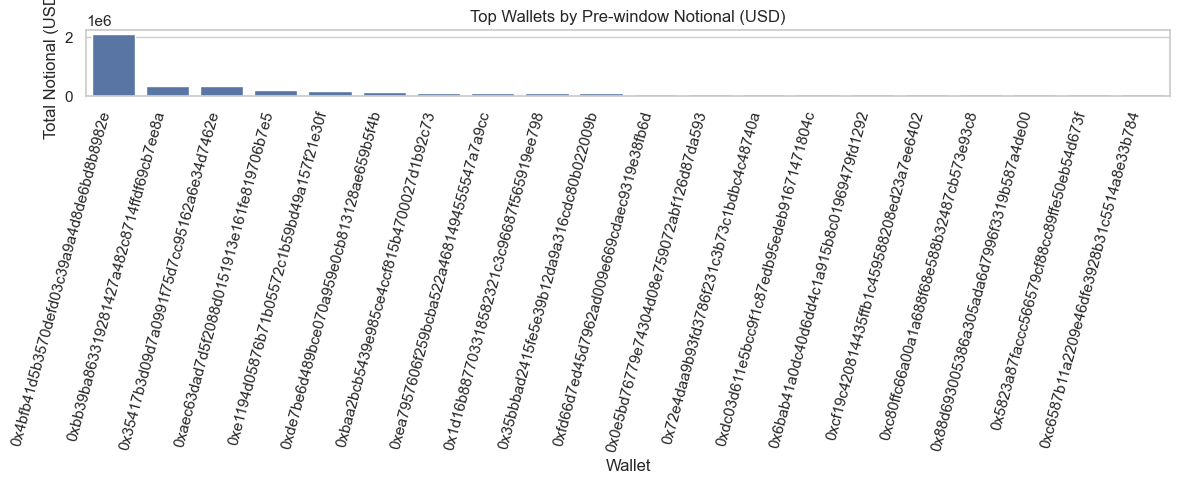

In [69]:
print("Validation checks")
print("- Event slug:", EVENT_SLUG)
print("- Anchor UTC:", ANCHOR_TS_UTC)
print("- Pre-window start UTC:", PRE_WINDOW_START_UTC)
print("- Pre-window hours:", PRE_WINDOW_HOURS)

if not submarkets_pre_anchor.empty:
    assert (submarkets_pre_anchor["launch_time"] <= ANCHOR_TS_UTC).all(), "Found submarket launched after anchor"
    print("- Pre-anchor submarket filter: PASS")
else:
    print("- Pre-anchor submarket filter: no rows")

if not pre_trades.empty:
    min_ts = pre_trades["block_time"].min()
    max_ts = pre_trades["block_time"].max()
    print("- Pre-window trade bounds:", min_ts, "->", max_ts)
    assert min_ts >= PRE_WINDOW_START_UTC, "Trade earlier than pre-window start"
    assert max_ts < ANCHOR_TS_UTC, "Trade at/after anchor included"
    print("- Pre-window bounds: PASS")
    april7_mask = pre_trades["question"].astype(str).str.contains("April 7", case=False, na=False)
    assert april7_mask.all(), "Found non-April-7 rows in section 5 output"
    print("- April 7 scope (from section 5 output): PASS")
else:
    print("- Pre-window bounds: no rows")

if not wallets_enriched.empty:
    plt.figure(figsize=(12, 5))
    plot_df = wallets_enriched.head(20).copy()
    sns.barplot(data=plot_df, x="wallet", y="total_notional_usd")
    plt.title("Top Wallets by Pre-window Notional (USD)")
    plt.xlabel("Wallet")
    plt.ylabel("Total Notional (USD)")
    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("- No wallets to visualize")


In [70]:
print("\nWallet Deep Dive")
TARGET_WALLET = "0x68558d37cafd9e6612ab32863f55ccdd798f655a".lower()
WALLET_TAG = TARGET_WALLET.replace("0x", "")[:10]
print("- Target wallet:", TARGET_WALLET)

wallet_info = pd.DataFrame()
wallet_all_trades = pd.DataFrame()
wallet_event_summary = pd.DataFrame()
wallet_question_outcome_summary = pd.DataFrame()

if not DUNE_API_KEY:
    raise RuntimeError("DUNE_API_KEY missing.")
else:
    wallet_info_sql = f"""
    SELECT DISTINCT
        lower(concat('0x', to_hex(polymarket_wallet))) AS polymarket_wallet,
        lower(concat('0x', to_hex(owner))) AS owner,
        wallet_type,
        created_time,
        first_funded_time,
        has_been_funded,
        lower(concat('0x', to_hex(created_tx_hash))) AS created_tx_hash,
        lower(concat('0x', to_hex(first_funded_by))) AS first_funded_by,
        lower(concat('0x', to_hex(first_funded_tx_hash))) AS first_funded_tx_hash
    FROM polymarket_polygon.users_address_lookup
    WHERE lower(concat('0x', to_hex(polymarket_wallet))) = {sql_quote(TARGET_WALLET)}
       OR lower(concat('0x', to_hex(owner))) = {sql_quote(TARGET_WALLET)}
    """

    info_res = dune_run_sql(wallet_info_sql, api_key=DUNE_API_KEY, performance="medium", limit=1000)
    wallet_info = dune_rows_to_df(info_res)

    if not wallet_info.empty:
        wallet_info["created_time"] = pd.to_datetime(wallet_info["created_time"], errors="coerce", utc=True)
        wallet_info["first_funded_time"] = pd.to_datetime(wallet_info["first_funded_time"], errors="coerce", utc=True)

    wallet_trades_sql = f"""
    SELECT
        date_trunc('month', block_time) AS block_month,
        block_number,
        block_time,
        lower(concat('0x', to_hex(tx_hash))) AS tx_hash,
        evt_index,
        action,
        lower(concat('0x', to_hex(contract_address))) AS contract_address,
        lower(concat('0x', to_hex(condition_id))) AS condition_id,
        event_market_name,
        question,
        token_outcome,
        CAST(asset_id AS VARCHAR) AS asset_id,
        price,
        amount,
        shares,
        lower(concat('0x', to_hex(maker))) AS maker,
        lower(concat('0x', to_hex(taker))) AS taker,
        CASE
            WHEN lower(concat('0x', to_hex(maker))) = {sql_quote(TARGET_WALLET)}
             AND lower(concat('0x', to_hex(taker))) = {sql_quote(TARGET_WALLET)} THEN 'maker+taker'
            WHEN lower(concat('0x', to_hex(maker))) = {sql_quote(TARGET_WALLET)} THEN 'maker'
            WHEN lower(concat('0x', to_hex(taker))) = {sql_quote(TARGET_WALLET)} THEN 'taker'
            ELSE 'other'
        END AS wallet_role,
        unique_key,
        token_outcome_name
    FROM polymarket_polygon.market_trades
    WHERE lower(concat('0x', to_hex(maker))) = {sql_quote(TARGET_WALLET)}
       OR lower(concat('0x', to_hex(taker))) = {sql_quote(TARGET_WALLET)}
    ORDER BY block_time DESC
    """

    trades_res = dune_run_sql(wallet_trades_sql, api_key=DUNE_API_KEY, performance="medium", limit=500000)
    wallet_all_trades = dune_rows_to_df(trades_res)

    if not wallet_all_trades.empty:
        wallet_all_trades["block_month"] = pd.to_datetime(wallet_all_trades["block_month"], errors="coerce", utc=True)
        wallet_all_trades["block_time"] = pd.to_datetime(wallet_all_trades["block_time"], errors="coerce", utc=True)
        for col in ["block_number", "evt_index", "price", "amount", "shares"]:
            wallet_all_trades[col] = pd.to_numeric(wallet_all_trades[col], errors="coerce")

        wallet_all_trades["is_maker"] = wallet_all_trades["wallet_role"].astype(str).str.contains("maker", na=False)
        wallet_all_trades["is_taker"] = wallet_all_trades["wallet_role"].astype(str).str.contains("taker", na=False)

        wallet_event_summary = (
            wallet_all_trades
            .groupby(["event_market_name", "question"], dropna=False, as_index=False)
            .agg(
                trade_count=("tx_hash", "count"),
                unique_tx_count=("tx_hash", "nunique"),
                total_notional_usd=("amount", "sum"),
                maker_trade_count=("is_maker", "sum"),
                taker_trade_count=("is_taker", "sum"),
                first_trade_time=("block_time", "min"),
                last_trade_time=("block_time", "max"),
            )
            .sort_values(["total_notional_usd", "trade_count"], ascending=[False, False])
        )

        wallet_question_outcome_summary = (
            wallet_all_trades
            .groupby(["event_market_name", "question", "token_outcome", "token_outcome_name"], dropna=False, as_index=False)
            .agg(
                trade_count=("tx_hash", "count"),
                total_notional_usd=("amount", "sum"),
                first_trade_time=("block_time", "min"),
                last_trade_time=("block_time", "max"),
            )
            .sort_values(["total_notional_usd", "trade_count"], ascending=[False, False])
        )

print("Wallet info rows:", len(wallet_info))
print("Wallet trades rows:", len(wallet_all_trades))
print("Distinct events/questions participated:", len(wallet_event_summary))

if not wallet_info.empty:
    display(wallet_info)
if not wallet_event_summary.empty:
    display(wallet_event_summary.head(30))
if not wallet_all_trades.empty:
    display(wallet_all_trades.head(30))

wallet_info.to_csv(OUTPUT_DIR / f"case_wallet_{WALLET_TAG}_info.csv", index=False)
wallet_all_trades.to_csv(OUTPUT_DIR / f"case_wallet_{WALLET_TAG}_all_trades.csv", index=False)
wallet_event_summary.to_csv(OUTPUT_DIR / f"case_wallet_{WALLET_TAG}_event_summary.csv", index=False)
wallet_question_outcome_summary.to_csv(OUTPUT_DIR / f"case_wallet_{WALLET_TAG}_question_outcome_summary.csv", index=False)

print("Saved:", OUTPUT_DIR / f"case_wallet_{WALLET_TAG}_info.csv")
print("Saved:", OUTPUT_DIR / f"case_wallet_{WALLET_TAG}_all_trades.csv")
print("Saved:", OUTPUT_DIR / f"case_wallet_{WALLET_TAG}_event_summary.csv")
print("Saved:", OUTPUT_DIR / f"case_wallet_{WALLET_TAG}_question_outcome_summary.csv")



Wallet Deep Dive
- Target wallet: 0x68558d37cafd9e6612ab32863f55ccdd798f655a
Wallet info rows: 1
Wallet trades rows: 303
Distinct events/questions participated: 1


,created_time,created_tx_hash,first_funded_by,first_funded_time,first_funded_tx_hash,has_been_funded,owner,polymarket_wallet,wallet_type
0,2026-04-07 13:54:47+00:00,0x79bb93af281d43ca0a927fbdc22e5e325dafb028c1e0...,0xf70da97812cb96acdf810712aa562db8dfa3dbef,2026-04-07 13:59:17+00:00,0x2d0f91dd7edcf2d9e0213e7973b3e01c899037d4e349...,True,0x7b6b6b07b04f5e49e127552056b795c3db7ef286,0x68558d37cafd9e6612ab32863f55ccdd798f655a,safe


,event_market_name,question,trade_count,unique_tx_count,total_notional_usd,maker_trade_count,taker_trade_count,first_trade_time,last_trade_time
0,single market,US x Iran ceasefire by April 7?,303,261,254534.421655,264,39,2026-04-07 13:59:47+00:00,2026-04-07 23:13:43+00:00


,action,amount,asset_id,block_month,block_number,block_time,condition_id,contract_address,event_market_name,evt_index,maker,price,question,shares,taker,token_outcome,token_outcome_name,tx_hash,unique_key,wallet_role,is_maker,is_taker
0,CLOB trade,3.11802,8285508889398582578135046681373728056400027572...,2026-04-01 00:00:00+00:00,85241793,2026-04-07 23:13:43+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,492,0x68558d37cafd9e6612ab32863f55ccdd798f655a,0.942,US x Iran ceasefire by April 7?,3.31,0x8dc13adfda28963976e8c17b1d4efbe53d14c34a,Yes,Yes-US x Iran ceasefire by April 7?,0xadaf8a0dafb48e3242af5811eca375bd8be5f4548041...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,maker,True,False
1,CLOB trade,0.13188,8285508889398582578135046681373728056400027572...,2026-04-01 00:00:00+00:00,85241793,2026-04-07 23:13:43+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,1398,0x68558d37cafd9e6612ab32863f55ccdd798f655a,0.942,US x Iran ceasefire by April 7?,0.14,0x42c229fd9ea41ccb89f7308c7c20919cdfa1b60d,Yes,Yes-US x Iran ceasefire by April 7?,0x522fc2964f8bbfb15755591feaf8a9daed2ead343237...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,maker,True,False
2,CLOB trade,3.53250,8285508889398582578135046681373728056400027572...,2026-04-01 00:00:00+00:00,85241793,2026-04-07 23:13:43+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,466,0x68558d37cafd9e6612ab32863f55ccdd798f655a,0.942,US x Iran ceasefire by April 7?,3.75,0x2db90f8bf381b2092654fe1de8950a1195ec846c,Yes,Yes-US x Iran ceasefire by April 7?,0x28201730830fab7115454a9f5cb123e6bd7686f3822e...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,maker,True,False
3,CLOB trade,0.19782,8285508889398582578135046681373728056400027572...,2026-04-01 00:00:00+00:00,85241793,2026-04-07 23:13:43+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,792,0x68558d37cafd9e6612ab32863f55ccdd798f655a,0.942,US x Iran ceasefire by April 7?,0.21,0xbbafe2685924f2a5a7b1100d3e67a017573c3996,Yes,Yes-US x Iran ceasefire by April 7?,0x2fbb044176217f3cff89dda682090a2cbcf58295ddf4...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,maker,True,False
4,CLOB trade,0.23550,8285508889398582578135046681373728056400027572...,2026-04-01 00:00:00+00:00,85241793,2026-04-07 23:13:43+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,770,0x68558d37cafd9e6612ab32863f55ccdd798f655a,0.942,US x Iran ceasefire by April 7?,0.25,0x85b87f40ee6adfa4b5b3f94bb8719dc379689d57,Yes,Yes-US x Iran ceasefire by April 7?,0xf749442dcd3f7b4f230644dc7a6f031c5674568884a8...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,maker,True,False
5,CLOB trade,0.05652,8285508889398582578135046681373728056400027572...,2026-04-01 00:00:00+00:00,85241793,2026-04-07 23:13:43+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,380,0x68558d37cafd9e6612ab32863f55ccdd798f655a,0.942,US x Iran ceasefire by April 7?,0.06,0x42c229fd9ea41ccb89f7308c7c20919cdfa1b60d,Yes,Yes-US x Iran ceasefire by April 7?,0xff414a4981d1a628a5fd3caa12597aebba1ed0191a73...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,maker,True,False
6,CLOB trade,15.59952,8285508889398582578135046681373728056400027572...,2026-04-01 00:00:00+00:00,85241793,2026-04-07 23:13:43+00:00,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,single market,603,0x68558d37cafd9e6612ab32863f55ccdd798f655a,0.942,US x Iran ceasefire by April 7?,16.56,0xbeccf1ec86abb15649df4d4023821f2f557ff560,Yes,Yes-US x Iran ceasefire by April 7?,0x10fd4b795e2e3d08a49d41bc14e0341f433f3fcf7ebb...,0x4c5701bcde0b8fb7d7f48c8e9d20245a6caa58c61a77...,maker,True,False
7,CLOB trade,3.08976,828550888939858257813504668137372805640

Saved: polymarket_outputs/case_wallet_68558d37ca_info.csv
Saved: polymarket_outputs/case_wallet_68558d37ca_all_trades.csv
Saved: polymarket_outputs/case_wallet_68558d37ca_event_summary.csv
Saved: polymarket_outputs/case_wallet_68558d37ca_question_outcome_summary.csv
